# PREDICTIONS

## LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from lib.graph import plot_cost_i_w, norm_plot
from lib.graph import dlc
from lib.ml_functions import predict_dot, gradient_descent_matrix, zscore_normalize_features
from lib.ml_functions import gradient_descent
from lib.data import load_text_data
plt.style.use('./lib/deeplearning.mplstyle')
plt.style.use('seaborn-v0_8')

sns.set_style('darkgrid')

## BACKEND

In [2]:
# load the dataset
X_train, y_train = load_text_data(file_name = '../../data/houses.txt', delimiter = ',', until_col = 4, skip_rows = 1)
X_features = ['size(sqft)','bedrooms','floors','age']

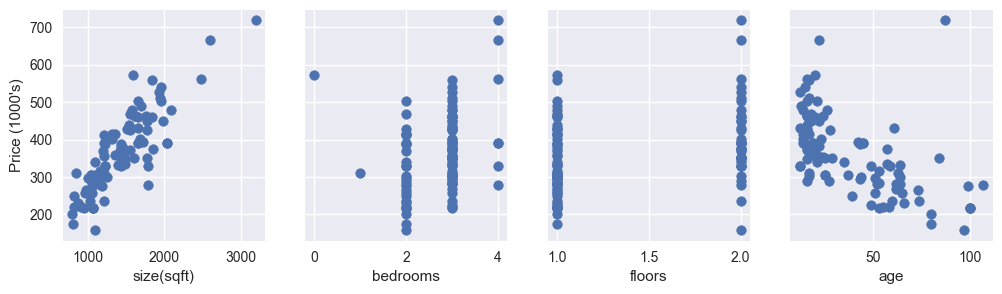

In [3]:
fig, ax = plt.subplots(1, 4, figsize = (12, 3), sharey = True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:, i], y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price (1000's)")
plt.show()

### $\alpha$ = 9.9e-7

In [4]:
_, n = X_train.shape
initial_w = np.zeros(n)
initial_b = 0
_, _, hist = gradient_descent_matrix(X_train, y_train, initial_w, initial_b, 9.9e-7, 1000)


Iteration         0: Cost  9.56e+04 w: [5.46265788e-01 9.95942280e-04 5.13326620e-04 1.22787176e-02] b:  3.60e-04 dj_dw: [-5.51783624e+05 -1.00600230e+03 -5.18511737e+02 -1.24027450e+04] dj_db: -3.63e+02
Iteration       100: Cost  8.15e+17 w: [8.64106003e+05 1.58577284e+03 8.25046714e+02 2.04761652e+04] b:  5.62e+02 dj_dw: [-1.62487430e+12 -2.98190563e+09 -1.55142834e+09 -3.85037235e+10] dj_db: -1.06e+09
Iteration       200: Cost  7.07e+30 w: [2.54466378e+12 4.66986724e+09 2.42964242e+09 6.02994532e+10] b:  1.65e+09 dj_dw: [-4.78501479e+18 -8.78127161e+15 -4.56872731e+15 -1.13387779e+17] dj_db: -3.11e+15
Iteration       300: Cost  6.13e+43 w: [7.49365893e+18 1.37520692e+16 7.15493801e+15 1.77572982e+17] b:  4.87e+15 dj_dw: [-1.40911617e+25 -2.58595477e+22 -1.34542270e+22 -3.33910261e+23] dj_db: -9.16e+21
Iteration       400: Cost  5.32e+56 w: [2.20677186e+25 4.04978122e+22 2.10702355e+22 5.22926200e+23] b:  1.44e+22 dj_dw: [-4.14963896e+31 -7.61525479e+28 -3.96207111e+28 -9.83316391e+2

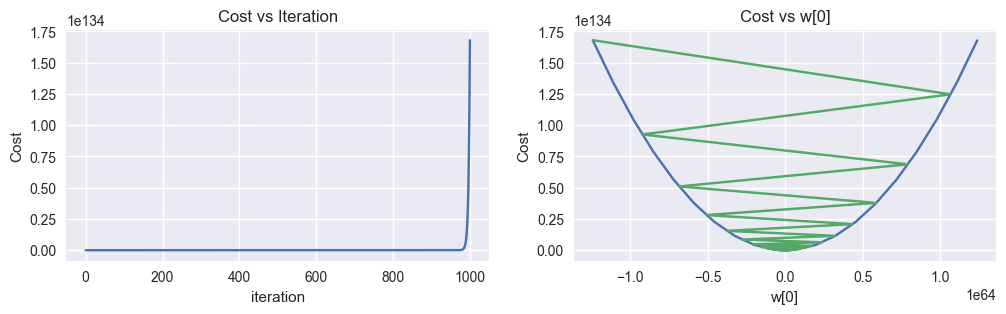

In [5]:
plot_cost_i_w(X_train, y_train, hist)

### $\alpha$ = 9e-7

In [6]:
_, _, hist = gradient_descent_matrix(X_train, y_train, initial_w, initial_b, 9e-7, 1000)

Iteration         0: Cost  6.65e+04 w: [4.96605262e-01 9.05402073e-04 4.66660564e-04 1.11624705e-02] b:  3.27e-04 dj_dw: [-5.51783624e+05 -1.00600230e+03 -5.18511737e+02 -1.24027450e+04] dj_db: -3.63e+02
Iteration       100: Cost  1.59e+03 w: [ 2.60576611e-01 -9.92794802e-05 -5.04796102e-04 -5.25142400e-02] b:  5.75e-04 dj_dw: [-1.44203408e+04 -2.03603347e+01 -5.51742490e+00  2.77738448e+02] dj_db: -1.40e+01
Iteration       200: Cost  1.51e+03 w: [ 0.25564675 -0.00063615 -0.00124872 -0.10612811] b:  9.97e-04 dj_dw: [-389.63248485    4.92216794    7.80575099  561.3009512 ] dj_db: -5.11e+00
Iteration       300: Cost  1.48e+03 w: [ 0.25665315 -0.00112188 -0.00198065 -0.15537688] b:  1.45e-03 dj_dw: [-22.27840519   5.16702729   8.08895365 524.95350615] dj_db: -5.10e+00
Iteration       400: Cost  1.46e+03 w: [ 0.25772492 -0.00157041 -0.00270668 -0.20073329] b:  1.91e-03 dj_dw: [-11.73169392   4.79098982   8.03680391 483.70875799] dj_db: -5.32e+00
Iteration       500: Cost  1.44e+03 w: [ 0.2

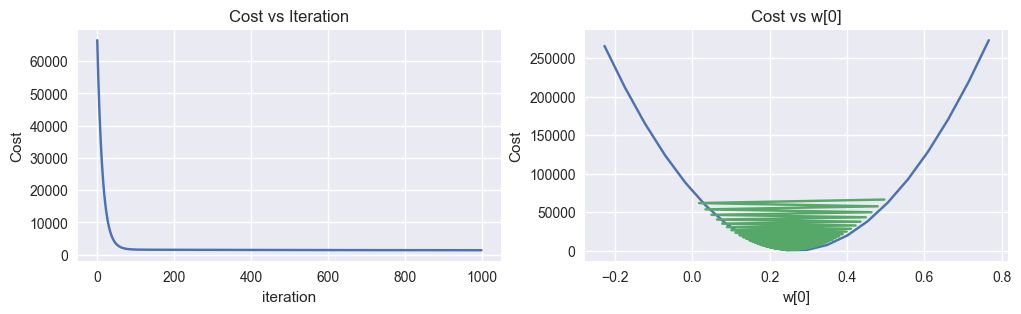

In [7]:
plot_cost_i_w(X_train, y_train, hist)

### $\alpha$ = 1e-7

In [8]:
_, _, hist = gradient_descent_matrix(X_train, y_train, initial_w, initial_b, 1e-7, 1000)

Iteration         0: Cost  4.42e+04 w: [5.51783624e-02 1.00600230e-04 5.18511737e-05 1.24027450e-03] b:  3.63e-05 dj_dw: [-5.51783624e+05 -1.00600230e+03 -5.18511737e+02 -1.24027450e+04] dj_db: -3.63e+02
Iteration       100: Cost  1.58e+03 w: [ 2.52981083e-01  3.97801044e-04  1.57452266e-04 -7.67153160e-04] b:  2.08e-04 dj_dw: [-15.80048755   6.52209498   8.30645688 666.06705577] dj_db: -4.36e+00
Iteration       200: Cost  1.57e+03 w: [ 2.53138361e-01  3.32870869e-04  7.44329534e-05 -7.39718574e-03] b:  2.52e-04 dj_dw: [-15.6567936    6.46460258   8.29750872 660.00926161] dj_db: -4.39e+00
Iteration       300: Cost  1.57e+03 w: [ 2.53294209e-01  2.68512972e-04 -8.49728862e-06 -1.39669190e-02] b:  2.96e-04 dj_dw: [-15.51441768   6.40763308   8.28864184 654.00656439] dj_db: -4.43e+00
Iteration       400: Cost  1.56e+03 w: [ 2.53448640e-01  2.04722151e-04 -9.13392692e-05 -2.04769015e-02] b:  3.41e-04 dj_dw: [-15.3733367    6.35118174   8.27985551 648.05846323] dj_db: -4.46e+00
Iteration   

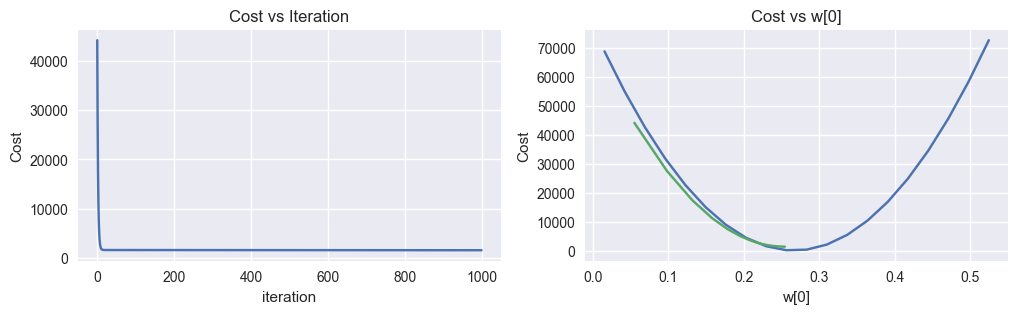

In [9]:
plot_cost_i_w(X_train, y_train, hist)

### Standarization

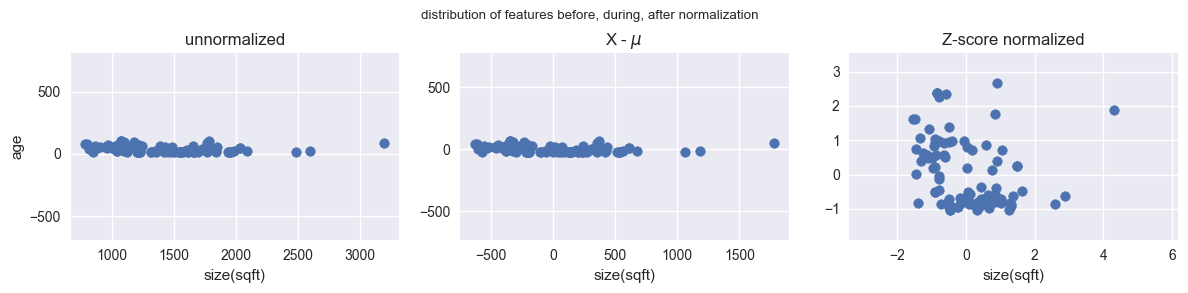

In [10]:
mu     = np.mean(X_train, axis = 0)
sigma  = np.std(X_train, axis = 0)
X_mean = (X_train - mu)
X_norm = (X_train - mu)/sigma 

fig,ax = plt.subplots(1, 3, figsize = (12, 3))
ax[0].scatter(X_train[:, 0], X_train[:, 3])
ax[0].set_xlabel(X_features[0])
ax[0].set_ylabel(X_features[3])
ax[0].set_title('unnormalized')
ax[0].axis('equal')

ax[1].scatter(X_mean[:, 0], X_mean[:, 3])
ax[1].set_xlabel(X_features[0])
ax[0].set_ylabel(X_features[3])
ax[1].set_title(r'X - $\mu$')
ax[1].axis('equal')

ax[2].scatter(X_norm[:, 0], X_norm[:, 3])
ax[2].set_xlabel(X_features[0])
ax[0].set_ylabel(X_features[3])
ax[2].set_title(r'Z-score normalized')
ax[2].axis('equal')
plt.tight_layout(rect = [0, 0.03, 1, 0.95])
fig.suptitle('distribution of features before, during, after normalization')
plt.show()

In [11]:
# normalize the original features
X_norm, X_mu, X_sigma = zscore_normalize_features(X_train)
print(f'X_mu = {X_mu}, \nX_sigma = {X_sigma}')
print(f'Peak to Peak range by column in Raw        X:{np.ptp(X_train, axis = 0)}')
print(f'Peak to Peak range by column in Normalized X:{np.ptp(X_norm, axis = 0)}')

X_mu = [1.41837374e+03 2.71717172e+00 1.38383838e+00 3.83838384e+01], 
X_sigma = [411.61562893   0.65196523   0.48631932  25.77788069]
Peak to Peak range by column in Raw        X:[2.406e+03 4.000e+00 1.000e+00 9.500e+01]
Peak to Peak range by column in Normalized X:[5.8452591  6.13529646 2.05626214 3.68533012]


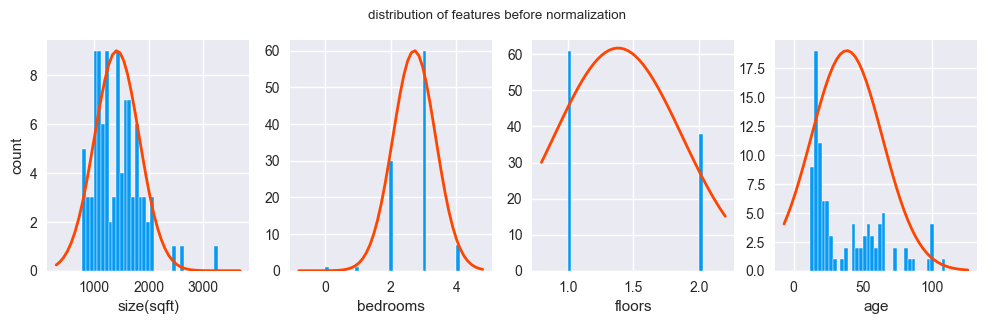

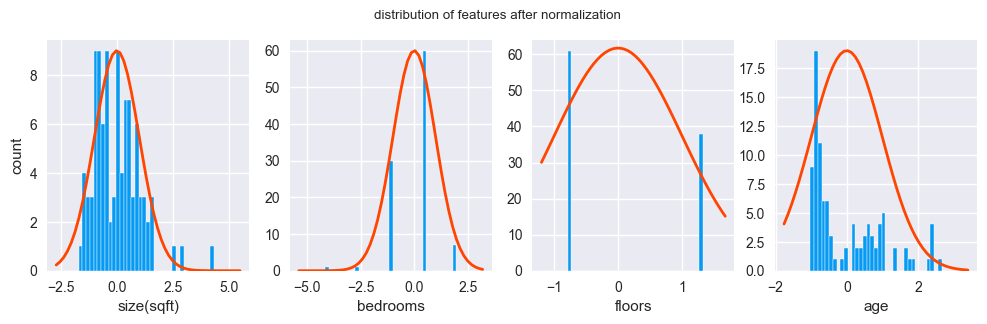

In [12]:
fig, ax = plt.subplots(1, 4, figsize = (12, 3))
for i in range(len(ax)):
    norm_plot(ax[i], X_train[:, i],)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel('count')
fig.suptitle('distribution of features before normalization')
plt.show()
fig, ax = plt.subplots(1, 4, figsize = (12, 3))
for i in range(len(ax)):
    norm_plot(ax[i], X_norm[:, i],)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel('count'); 
fig.suptitle('distribution of features after normalization')

plt.show()

### With Normalization and $\alpha$ = 3.0e-1

In [13]:
_, n = X_norm.shape
initial_w = np.zeros(n)
initial_b = 0
w_norm, b_norm, hist = gradient_descent_matrix(X_norm, y_train, initial_w, initial_b, 3.0e-1, 1000000)
print(f'w,b found by gradient descent: w: {w_norm}, b: {b_norm: 0.2f}')


Iteration         0: Cost  3.48e+04 w: [ 26.74284489   8.85547433   9.84687191 -17.88253234] b:  1.09e+02 dj_dw: [-89.1428163  -29.51824777 -32.82290635  59.60844113] dj_db: -3.63e+02
Iteration    100000: Cost  2.19e+02 w: [110.56039756 -21.26715096 -32.70718139 -37.97015909] b:  3.63e+02 dj_dw: [-2.18904580e-14  8.61263922e-16  2.87087974e-15 -1.50721186e-15] dj_db: -3.96e-14
Iteration    200000: Cost  2.19e+02 w: [110.56039756 -21.26715096 -32.70718139 -37.97015909] b:  3.63e+02 dj_dw: [-2.18904580e-14  8.61263922e-16  2.87087974e-15 -1.50721186e-15] dj_db: -3.96e-14
Iteration    300000: Cost  2.19e+02 w: [110.56039756 -21.26715096 -32.70718139 -37.97015909] b:  3.63e+02 dj_dw: [-2.18904580e-14  8.61263922e-16  2.87087974e-15 -1.50721186e-15] dj_db: -3.96e-14
Iteration    400000: Cost  2.19e+02 w: [110.56039756 -21.26715096 -32.70718139 -37.97015909] b:  3.63e+02 dj_dw: [-2.18904580e-14  8.61263922e-16  2.87087974e-15 -1.50721186e-15] dj_db: -3.96e-14
Iteration    500000: Cost  2.19e

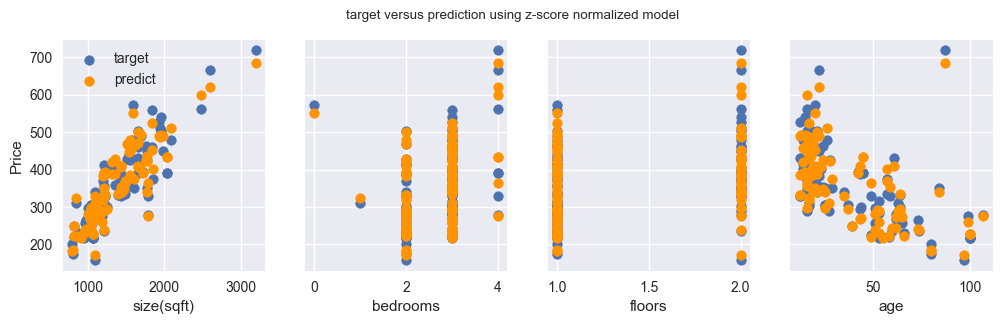

In [14]:
#predict target using normalized features
m = X_norm.shape[0]
yp = np.zeros(m)
for i in range(m):
    # yp[i] = np.dot(X_norm[i], w_norm) + b_norm
    yp[i] = predict_dot(X_norm[i], w_norm, b_norm)

    # plot predictions and targets versus original features    
fig, ax = plt.subplots(1,4,figsize = (12, 3), sharey = True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:, i], y_train, label = 'target')
    ax[i].set_xlabel(X_features[i])
    ax[i].scatter(X_train[:, i], yp,color = dlc['dlorange'], label = 'predict')
ax[0].set_ylabel('Price')
ax[0].legend()
fig.suptitle('target versus prediction using z-score normalized model')
plt.show()

In [15]:
yp[:4]

array([295.17615301, 485.97796332, 389.52416548, 492.14712499])

In [16]:
y_train[:4]

array([300. , 509.8, 394. , 540. ])

In [17]:
# First, normalize out example.
x_house = np.array([500, 3, 3, 20])
x_house_norm = (x_house - X_mu) / X_sigma
print(x_house_norm)
# x_house_predict = np.dot(x_house_norm, w_norm) + b_norm
x_house_predict = predict_dot(x_house_norm, w_norm, b_norm)
print(f' predicted price of a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old = ${x_house_predict * 1000: 0.0f}')

[-2.23114399  0.43380884  3.32325194 -0.7131633 ]
 predicted price of a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old = $ 25639


### Temperature Prediction

In [18]:
print ('Leyendo CSV')
temperature_df = pd.read_csv('../../data/celsius_a_fahrenheit.csv')
print('TEMPERATURE DF:')
print(temperature_df)

Leyendo CSV
TEMPERATURE DF:
    Celsius  Fahrenheit
0       -50       -58.0
1       -40       -40.0
2       -30       -22.0
3       -20        -4.0
4       -10        14.0
5        -9        15.8
6        -8        17.6
7        -7        19.4
8        -6        21.2
9        -5        23.0
10       -4        24.8
11       -3        26.6
12       -2        28.4
13       -1        30.2
14        0        32.0
15        1        33.8
16        2        35.6
17        3        37.4
18        4        39.2
19        5        41.0
20        6        42.8
21        7        44.6
22        8        46.4
23        9        48.2
24       10        50.0
25       20        68.0
26       30        86.0
27       40       104.0
28       50       122.0
29       60       140.0


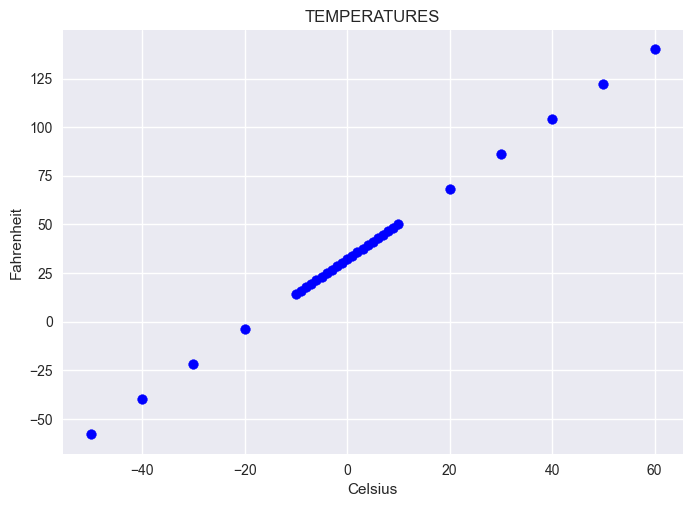

In [19]:
# Plot the data points
plt.scatter(x = temperature_df['Celsius'], y = temperature_df['Fahrenheit'], marker='o', c='b')
# Set the title
plt.title('TEMPERATURES')
# Set the y-axis label
plt.ylabel('Fahrenheit')
# Set the x-axis label
plt.xlabel('Celsius')
plt.show()

In [20]:
training_data = temperature_df.sample(frac = 0.8, random_state = 0)
training_label = training_data.pop('Fahrenheit')

In [21]:
# initialize parameters
w_init = 0
b_init = 0
# some gradient descent settings
iterations = 3100
tmp_alpha = 3.0e-3
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(training_data['Celsius'].to_numpy(), training_label.to_numpy(), w_init, b_init, tmp_alpha, iterations)
print(f'(w, b) found by gradient descent: ({w_final:8.4f}, {b_final:8.4f})')

Iteration         0: Cost  7.32e+02  w:  3.075e+00, b: 1.19e-01 dj_dw: -1.02e+03, dj_db: -3.98e+01
Iteration       310: Cost  8.15e+01  w:  1.915e+00, b: 1.90e+01 dj_dw:  1.11e-01, dj_db: -1.26e+01
Iteration       620: Cost  1.36e+01  w:  1.847e+00, b: 2.67e+01 dj_dw:  4.52e-02, dj_db: -5.13e+00
Iteration       930: Cost  2.27e+00  w:  1.819e+00, b: 2.98e+01 dj_dw:  1.85e-02, dj_db: -2.09e+00
Iteration      1240: Cost  3.78e-01  w:  1.808e+00, b: 3.11e+01 dj_dw:  7.54e-03, dj_db: -8.55e-01
Iteration      1550: Cost  6.30e-02  w:  1.803e+00, b: 3.16e+01 dj_dw:  3.08e-03, dj_db: -3.49e-01
Iteration      1860: Cost  1.05e-02  w:  1.801e+00, b: 3.19e+01 dj_dw:  1.26e-03, dj_db: -1.43e-01
Iteration      2170: Cost  1.75e-03  w:  1.801e+00, b: 3.19e+01 dj_dw:  5.13e-04, dj_db: -5.82e-02
Iteration      2480: Cost  2.92e-04  w:  1.800e+00, b: 3.20e+01 dj_dw:  2.10e-04, dj_db: -2.38e-02
Iteration      2790: Cost  4.86e-05  w:  1.800e+00, b: 3.20e+01 dj_dw:  8.55e-05, dj_db: -9.70e-03

Final Ite

In [22]:
print(f'w: {w_final:0.2f} ---- b: {b_final:0.2f}')
print(f'25 °C prediction: {w_final * 25 + b_final: 0.1f} °F')
print(f'30  °C prediction: {w_final * 30 + b_final: 0.1f} °F')
print(f'15  °C prediction: {w_final * 15 + b_final: 0.1f} °F')

w: 1.80 ---- b: 32.00
25 °C prediction:  77.0 °F
30  °C prediction:  86.0 °F
15  °C prediction:  59.0 °F


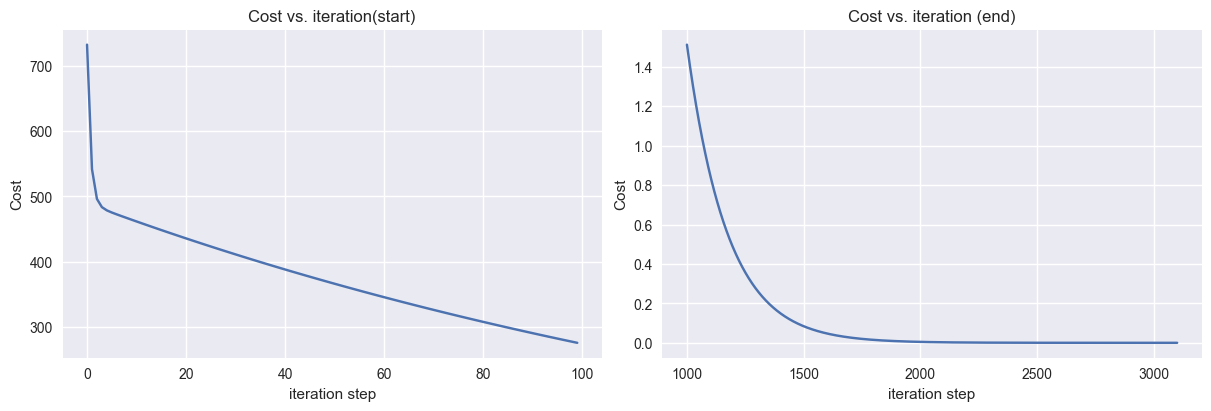

In [ ]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title('Cost vs. iteration(start)');  ax2.set_title('Cost vs. iteration (end)')
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()
